In [1]:
# Step 0: Set Global Seed for Reproducibility
import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [2]:
# ============================================================
# Publication-Quality Plot Settings (A4 Paper Compatible)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

plt.rcParams.update({
    "figure.dpi":         150,
    "savefig.dpi":        600,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.15,
    "pdf.fonttype":       42,
    "ps.fonttype":        42,
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size":          16,
    "axes.titlesize":     22,
    "axes.labelsize":     18,
    "xtick.labelsize":    15,
    "ytick.labelsize":    15,
    "legend.fontsize":    15,
    "figure.titlesize":   24,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          False,
    "axes.linewidth":     1.2,
    "lines.linewidth":    2.0,
})

# Colour-blind-safe Okabe-Ito palette
CB_PALETTE = ["#E69F00", "#56B4E9", "#009E73", "#F0E442",
              "#0072B2", "#D55E00", "#CC79A7", "#999999"]
sns.set_palette(CB_PALETTE)

print("Publication-quality plot settings applied (A4-compatible, 600 DPI).")

Publication-quality plot settings applied (A4-compatible, 600 DPI).


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="Mvt9FCxE4mY6vBy5OG08")
project = rf.workspace("urban-lake-wastef").project("extened_dataset-of-waste-classification")
version = project.version(3)
dataset = version.download("coco-segmentation")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 64.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 117.8 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.21.0 requires google-cloud-bigquery-s


Extracting Dataset Version Zip to Extened_Dataset-of-Waste-Classification-3 in coco-segmentation:: 100%|██████████| 1955/1955 [00:00<00:00, 6157.66it/s]


In [4]:
# Step 3: Extract foreground objects from COCO masks (excluding junk classes)
# Extracts from ALL Roboflow splits (train + valid + test) so the full dataset
# is available — matching the same data pool used by the Mask R-CNN notebook.
import os
import json
import shutil
import numpy as np
from PIL import Image, ImageDraw
from tqdm import tqdm
from collections import defaultdict

DATA_ROOT = dataset.location

# Define output directories
REGION_ROOT = '/content/extracted_regions'
SPLIT_ROOT = '/content/split_regions'

# Clean output directories to prevent stale files from previous runs
for _d in [REGION_ROOT, SPLIT_ROOT]:
    if os.path.exists(_d):
        shutil.rmtree(_d)
os.makedirs(REGION_ROOT, exist_ok=True)

# Classes to exclude (zero/junk data)
EXCLUDE_CLASSES = {"Organic-Paper-Rubber-yUNM-9Y5P-Teq0"}

saved = 0
region_to_source = {}  # region_filename -> source_image_id (for image-level splitting)

# Process ALL three Roboflow splits so the data pool matches the Mask R-CNN notebook
for split_name in ['train', 'valid', 'test']:
    ann_path = os.path.join(DATA_ROOT, split_name, '_annotations.coco.json')
    img_dir  = os.path.join(DATA_ROOT, split_name)

    if not os.path.exists(ann_path):
        print(f"Skipping {split_name}: {ann_path} not found")
        continue

    with open(ann_path) as f:
        ann_data = json.load(f)

    cat_map = {c['id']: c['name'] for c in ann_data['categories']}
    img_map = {img['id']: img for img in ann_data['images']}

    exclude_cat_ids = {cid for cid, name in cat_map.items() if name in EXCLUDE_CLASSES}

    # Group annotations by image_id (skip excluded categories)
    anns_by_image = defaultdict(list)
    for ann in ann_data['annotations']:
        if ann['category_id'] not in exclude_cat_ids:
            anns_by_image[ann['image_id']].append(ann)

    print(f"\n[{split_name}] {len(img_map)} images, "
          f"{sum(len(v) for v in anns_by_image.values())} annotations (after exclusion)")

    for image_id, anns in tqdm(anns_by_image.items(), desc=f"Extracting [{split_name}]"):
        img_info = img_map[image_id]
        img_path = os.path.join(img_dir, img_info['file_name'])

        try:
            img = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Warning: could not open {img_path}: {e}")
            continue

        img_arr = np.array(img)
        h, w = img_info['height'], img_info['width']

        for ann in anns:
            seg = ann['segmentation']
            mask = np.zeros((h, w), dtype=np.uint8)

            for poly in seg:
                pts = np.array(poly).reshape(-1, 2)
                m = Image.new('L', (w, h), 0)
                ImageDraw.Draw(m).polygon([tuple(p) for p in pts], outline=1, fill=1)
                mask = np.maximum(mask, np.array(m))

            region = img_arr * mask[:, :, None]
            region_img = Image.fromarray(region)

            label = cat_map[ann['category_id']]
            out_dir = os.path.join(REGION_ROOT, label)
            os.makedirs(out_dir, exist_ok=True)
            # Include split_name in filename to avoid collisions across splits
            base = os.path.splitext(img_info['file_name'])[0]
            region_fname = f"{split_name}_{base}_{ann['id']}.jpg"
            out_path = os.path.join(out_dir, region_fname)
            region_img.save(out_path, format='JPEG', quality=95)
            saved += 1

            # Track source: split_name + image_id makes a globally unique source key
            region_to_source[region_fname] = f"{split_name}_{image_id}"

# Save region-to-source mapping for image-level splitting
mapping_path = os.path.join(REGION_ROOT, 'region_to_source.json')
with open(mapping_path, 'w') as f:
    json.dump(region_to_source, f)

print(f"\nRegion extraction complete. Saved: {saved}")
print(f"Excluded {len(EXCLUDE_CLASSES)} junk class(es): {EXCLUDE_CLASSES}")
print(f"Regions saved to: {REGION_ROOT}")
print(f"Source mapping saved to: {mapping_path}")


[train] 1795 images, 3559 annotations (after exclusion)


Extracting [train]: 100%|██████████| 1674/1674 [00:13<00:00, 119.61it/s]



[valid] 103 images, 249 annotations (after exclusion)


Extracting [valid]: 100%|██████████| 101/101 [00:00<00:00, 111.20it/s]



[test] 49 images, 92 annotations (after exclusion)


Extracting [test]: 100%|██████████| 48/48 [00:00<00:00, 130.43it/s]


Region extraction complete. Saved: 3900
Excluded 1 junk class(es): {'Organic-Paper-Rubber-yUNM-9Y5P-Teq0'}
Regions saved to: /content/extracted_regions
Source mapping saved to: /content/extracted_regions/region_to_source.json


In [5]:
# Step 4: Image-level stratified split (70% train, 20% val, 10% test)
# Replicates the Mask R-CNN merge-and-split pipeline to guarantee IDENTICAL
# image assignments across all notebooks.
import shutil
import json
import numpy as np
from collections import defaultdict, Counter
from sklearn.model_selection import StratifiedShuffleSplit
from tqdm import tqdm

DATA_ROOT = dataset.location
EXCLUDE_CLASSES = {"Organic-Paper-Rubber-yUNM-9Y5P-Teq0"}

# ── A. Merge all Roboflow splits (identical logic to Mask R-CNN) ──
merged_images = []
merged_anns   = []
id_to_source  = {}          # merged_img_id → "split_originalid" (matches region_to_source values)
next_img = next_ann = 1

for split_name in ['train', 'valid', 'test']:
    with open(os.path.join(DATA_ROOT, split_name, '_annotations.coco.json')) as f:
        coco = json.load(f)
    excl_ids = {c['id'] for c in coco['categories'] if c['name'] in EXCLUDE_CLASSES}
    old2new  = {}

    for img in coco['images']:
        old2new[img['id']] = next_img
        id_to_source[next_img] = f"{split_name}_{img['id']}"
        merged_images.append({**img, 'id': next_img})
        next_img += 1

    for ann in coco['annotations']:
        if ann['category_id'] in excl_ids:
            continue
        new_id = old2new.get(ann['image_id'])
        if new_id:
            merged_anns.append({**ann, 'id': next_ann, 'image_id': new_id})
            next_ann += 1

print(f"Merged pool: {len(merged_images)} images, {len(merged_anns)} annotations (excl. junk)")

# ── B. Dominant class per image (identical to Mask R-CNN) ──
anns_by_img = defaultdict(list)
for ann in merged_anns:
    anns_by_img[ann['image_id']].append(ann['category_id'])

all_ids = np.array([img['id'] for img in merged_images])
labels  = np.array([
    Counter(anns_by_img[i]).most_common(1)[0][0] if i in anns_by_img else -1
    for i in all_ids
])

# ── C. Stratified split — identical params to Mask R-CNN ──
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=42)
trainval_idx, test_idx = next(sss1.split(all_ids, labels))

val_frac_adj = 0.20 / (1 - 0.10)   # ≈ 0.2222
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=val_frac_adj, random_state=42)
train_idx, val_idx = next(sss2.split(all_ids[trainval_idx], labels[trainval_idx]))

train_img_ids = set(all_ids[trainval_idx[train_idx]])
val_img_ids   = set(all_ids[trainval_idx[val_idx]])
test_img_ids  = set(all_ids[test_idx])

assert train_img_ids.isdisjoint(val_img_ids),  "Train/Val overlap!"
assert train_img_ids.isdisjoint(test_img_ids), "Train/Test overlap!"
assert val_img_ids.isdisjoint(test_img_ids),   "Val/Test overlap!"
print(f"Split — Train: {len(train_img_ids)} imgs, Val: {len(val_img_ids)} imgs, Test: {len(test_img_ids)} imgs")

# ── D. Map merged IDs → source keys and assign regions ──
train_srcs = {id_to_source[i] for i in train_img_ids}
val_srcs   = {id_to_source[i] for i in val_img_ids}
test_srcs  = {id_to_source[i] for i in test_img_ids}

with open(os.path.join(REGION_ROOT, 'region_to_source.json')) as f:
    region_to_source = json.load(f)

all_regions = []
for class_name in sorted(os.listdir(REGION_ROOT)):
    class_path = os.path.join(REGION_ROOT, class_name)
    if not os.path.isdir(class_path):
        continue
    for fname in os.listdir(class_path):
        if fname.endswith(('.jpg', '.jpeg', '.png')):
            src_id = region_to_source.get(fname, fname)
            all_regions.append((class_name, fname, src_id))

# Clean split directory to prevent stale files from previous runs
if os.path.exists(SPLIT_ROOT):
    shutil.rmtree(SPLIT_ROOT)
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(SPLIT_ROOT, split), exist_ok=True)

split_counts = Counter()
for class_name, fname, src_id in tqdm(all_regions, desc="Splitting regions"):
    if src_id in train_srcs:
        split = 'train'
    elif src_id in val_srcs:
        split = 'val'
    else:
        split = 'test'

    dst_dir = os.path.join(SPLIT_ROOT, split, class_name)
    os.makedirs(dst_dir, exist_ok=True)
    shutil.copy2(
        os.path.join(REGION_ROOT, class_name, fname),
        os.path.join(dst_dir, fname)
    )
    split_counts[split] += 1

print(f"\nImage-level stratified split complete (identical to Mask R-CNN):")
print(f"  Train : {split_counts['train']:>5d} regions from {len(train_srcs)} source images")
print(f"  Val   : {split_counts['val']:>5d} regions from {len(val_srcs)} source images")
print(f"  Test  : {split_counts['test']:>5d} regions from {len(test_srcs)} source images")

Merged pool: 1947 images, 3900 annotations (excl. junk)
Split — Train: 1362 imgs, Val: 390 imgs, Test: 195 imgs


Splitting regions: 100%|██████████| 3900/3900 [00:00<00:00, 6970.14it/s]


Image-level stratified split complete (identical to Mask R-CNN):
  Train :  2736 regions from 1362 source images
  Val   :   747 regions from 390 source images
  Test  :   417 regions from 195 source images


Class distribution across splits:


Split,Train,Val,Test,Total,Dataset %
Class,,,,,
Composite_Rubber_Textile,393.0,109.0,57.0,559.0,14.3
Organic,509.0,144.0,78.0,731.0,18.7
Paper,502.0,131.0,84.0,717.0,18.4
Plastic,1332.0,363.0,198.0,1893.0,48.5




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



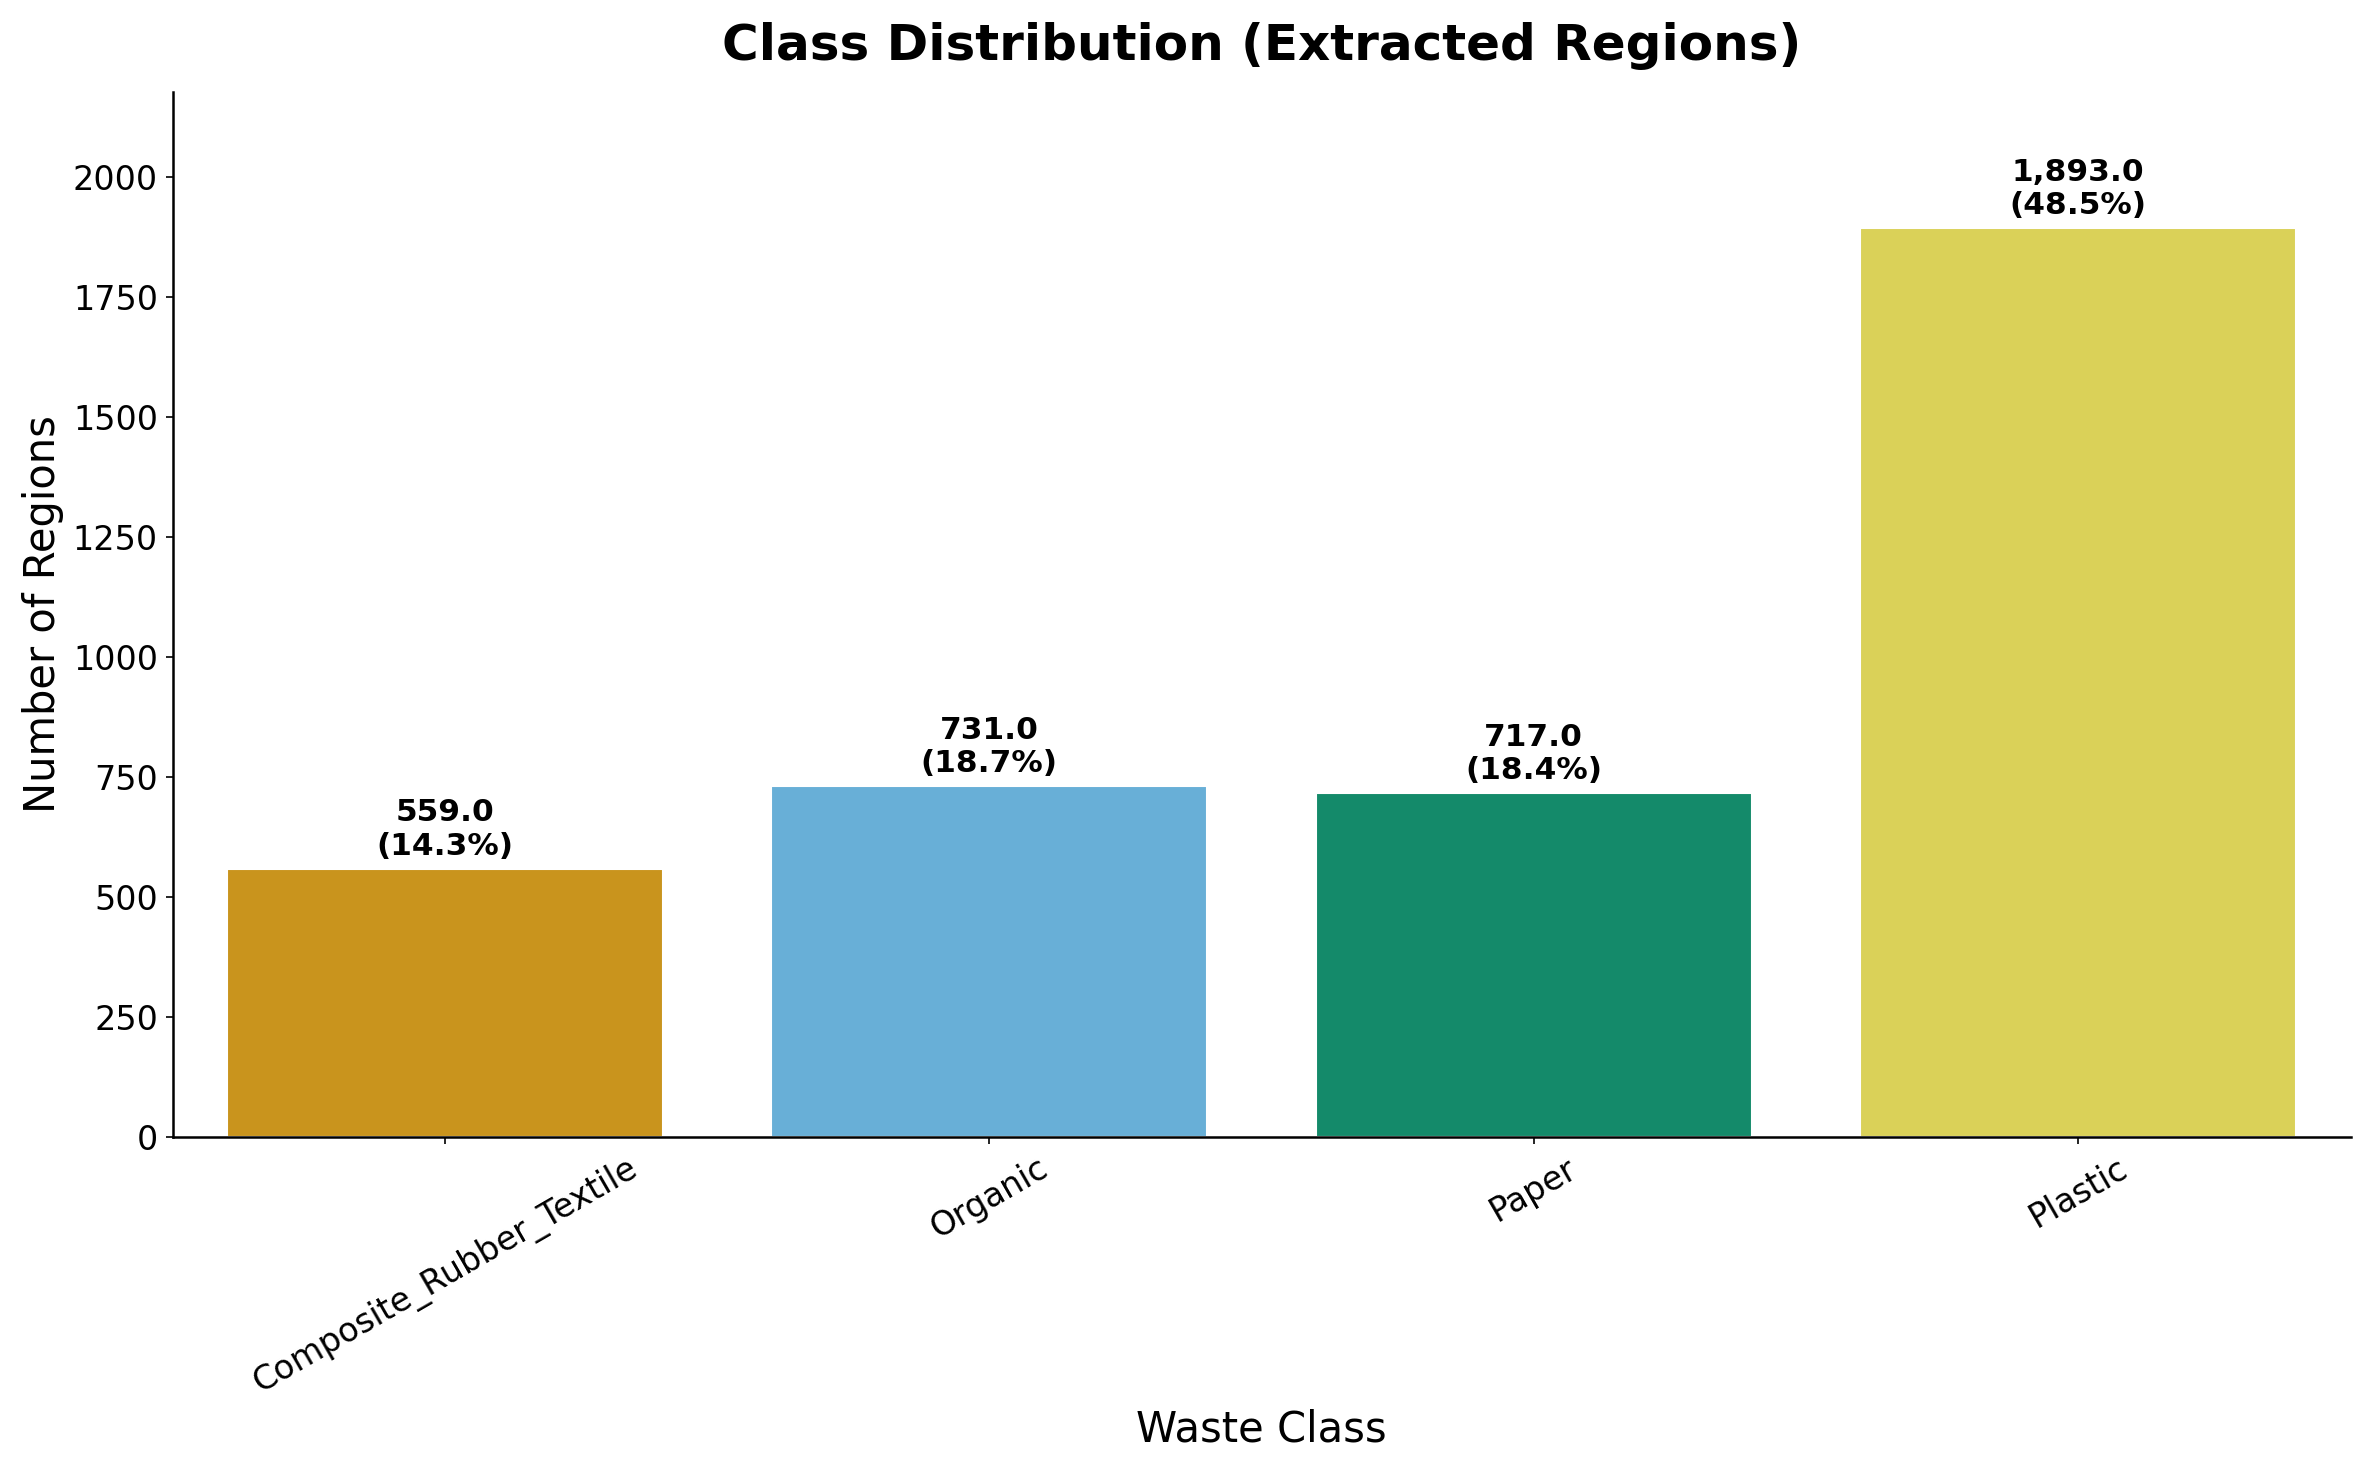

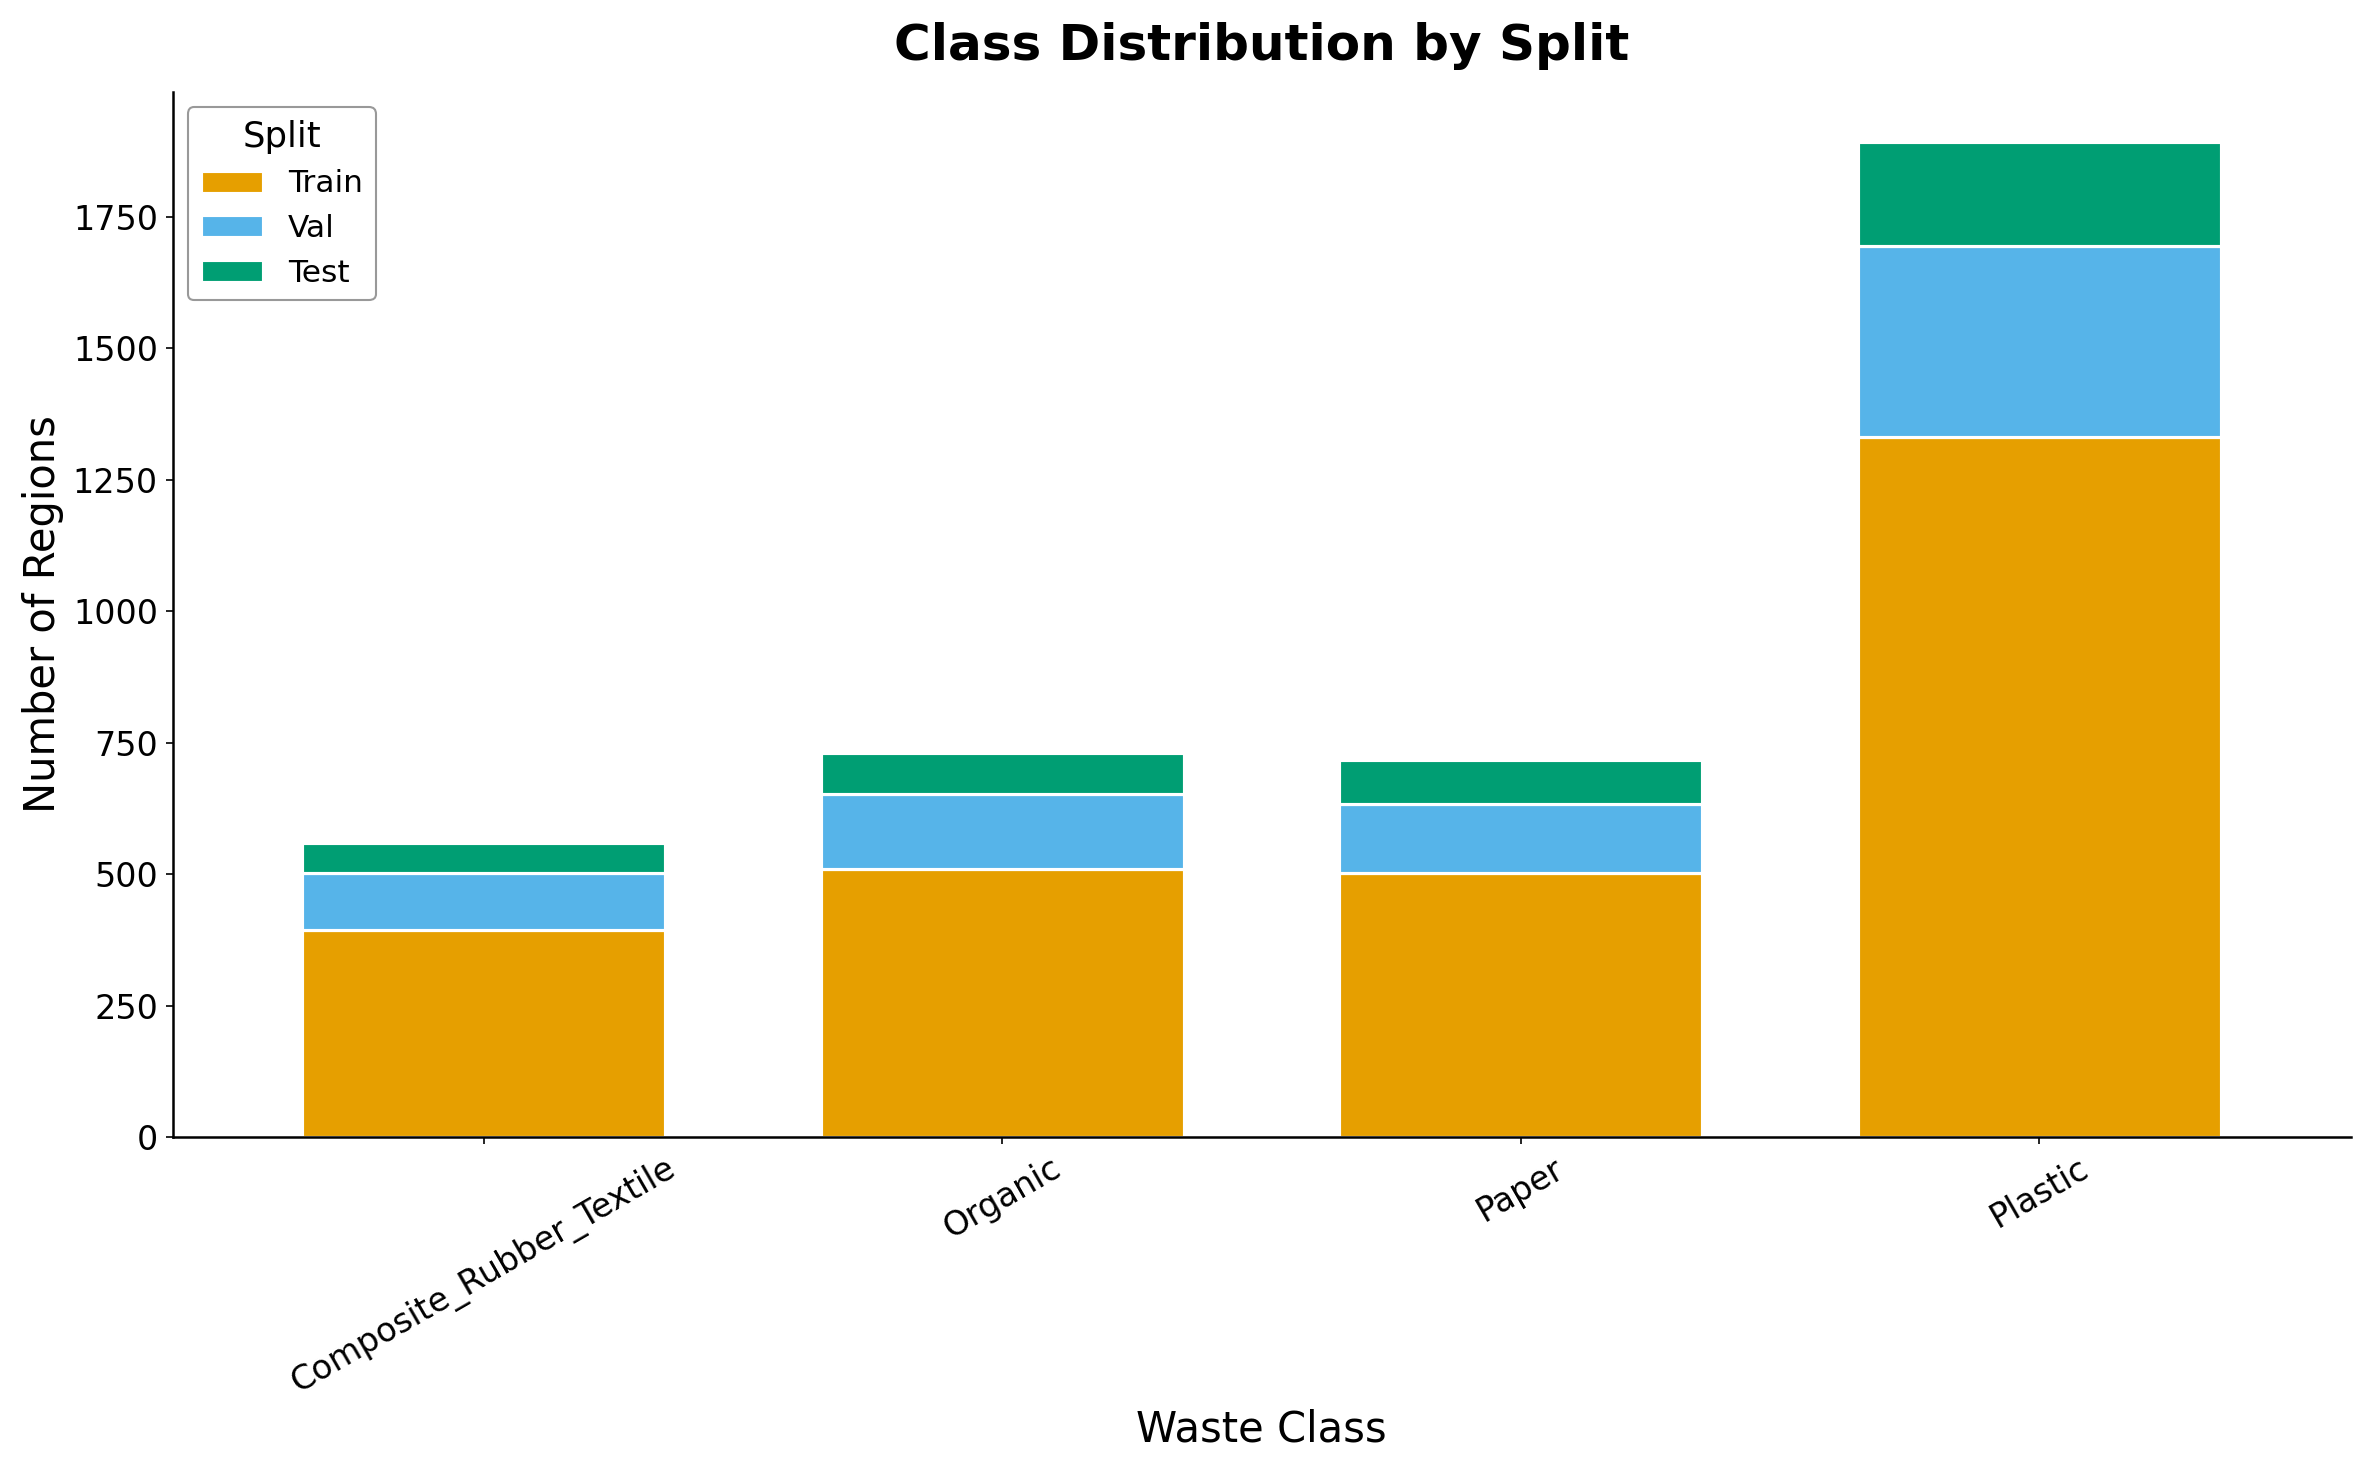


Class Imbalance Analysis:
  Imbalance ratio: 3.4:1
  Most frequent:  'Plastic' — 1,893.0 (48.5%)
  Least frequent: 'Composite_Rubber_Textile' — 559.0 (14.3%)


In [6]:
# Step 4b: Visualize class distribution across splits
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

split_data = []
for split in ['train', 'val', 'test']:
    split_dir = os.path.join(SPLIT_ROOT, split)
    for class_name in sorted(os.listdir(split_dir)):
        class_dir = os.path.join(split_dir, class_name)
        if os.path.isdir(class_dir):
            count = len([f for f in os.listdir(class_dir)
                         if f.endswith(('.jpg', '.jpeg', '.png'))])
            split_data.append({'Class': class_name, 'Split': split.capitalize(),
                               'Count': count})

df = pd.DataFrame(split_data)

# Summary table
df_wide = df.pivot_table(index='Class', columns='Split', values='Count', fill_value=0)
df_wide = df_wide[['Train', 'Val', 'Test']]
df_wide['Total'] = df_wide.sum(axis=1)
total_all = df_wide['Total'].sum()
df_wide['Dataset %'] = (df_wide['Total'] / total_all * 100).round(1)
print("Class distribution across splits:")
display(df_wide)

# Bar chart: total class distribution
df_total = df_wide[['Total', 'Dataset %']].reset_index()

fig, ax = plt.subplots(figsize=(16, 10))
sns.barplot(x='Class', y='Total', data=df_total, palette=CB_PALETTE[:len(df_total)],
            edgecolor='white', ax=ax)
ax.set_title('Class Distribution (Extracted Regions)', fontsize=24, fontweight='bold', pad=15)
ax.set_xlabel('Waste Class', fontsize=20)
ax.set_ylabel('Number of Regions', fontsize=20)
ax.tick_params(axis='x', rotation=30, labelsize=16)
ax.tick_params(axis='y', labelsize=16)
for i, row in df_total.iterrows():
    ax.text(i, row['Total'] + df_total['Total'].max() * 0.015,
            f"{row['Total']:,}\n({row['Dataset %']:.1f}%)",
            ha='center', fontsize=15, fontweight='bold')
ax.set_ylim(0, df_total['Total'].max() * 1.15)
plt.tight_layout()
plt.show()

# Stacked bar chart: split distribution
df_pivot = df.pivot_table(index='Class', columns='Split', values='Count', fill_value=0)
df_pivot = df_pivot[['Train', 'Val', 'Test']]

fig, ax = plt.subplots(figsize=(16, 10))
df_pivot.plot(kind='bar', stacked=True, ax=ax, color=CB_PALETTE[:3],
              edgecolor='white', width=0.7, linewidth=1.5)
ax.set_title('Class Distribution by Split', fontsize=24, fontweight='bold', pad=15)
ax.set_xlabel('Waste Class', fontsize=20)
ax.set_ylabel('Number of Regions', fontsize=20)
ax.tick_params(axis='x', rotation=30, labelsize=16)
ax.tick_params(axis='y', labelsize=16)
ax.legend(title='Split', fontsize=15, title_fontsize=17, frameon=True, edgecolor='gray')
plt.tight_layout()
plt.show()

# Imbalance summary
max_cls = df_total.loc[df_total['Total'].idxmax()]
min_cls = df_total.loc[df_total['Total'].idxmin()]
print(f"\nClass Imbalance Analysis:")
print(f"  Imbalance ratio: {(max_cls['Total'] / min_cls['Total']):.1f}:1")
print(f"  Most frequent:  '{max_cls['Class']}' — {max_cls['Total']:,} ({max_cls['Dataset %']}%)")
print(f"  Least frequent: '{min_cls['Class']}' — {min_cls['Total']:,} ({min_cls['Dataset %']}%)")

In [7]:
# Step 5: Define PyTorch Dataset with balanced sampling
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from collections import defaultdict

class RoadConditionDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform or transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
        self.label2id = {}
        class_counts = defaultdict(int)

        # Collect all image paths and assign class indices
        classes = sorted(os.listdir(root_dir))
        self.label2id = {c: i for i, c in enumerate(classes)}
        self.id2label = {i: c for i, c in enumerate(classes)}

        for c in classes:
            class_dir = os.path.join(root_dir, c)
            if not os.path.isdir(class_dir):
                continue

            for f in os.listdir(class_dir):
                if f.endswith(('.png', '.jpg', '.jpeg')):
                    self.samples.append((os.path.join(class_dir, f), self.label2id[c]))
                    class_counts[self.label2id[c]] += 1

        # Print class distribution
        print(f"Class distribution: {dict(class_counts)}")

        # Compute sample weights for balancing
        self.sample_weights = [1.0 / class_counts[label] for _, label in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label

# Define paths to the dataset splits
TRAIN_DIR = os.path.join(SPLIT_ROOT, 'train')
VAL_DIR = os.path.join(SPLIT_ROOT, 'val')
TEST_DIR = os.path.join(SPLIT_ROOT, 'test')

# Transform for validation/test (no augmentation)
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create dataset instances
train_ds = RoadConditionDataset(TRAIN_DIR)
val_ds = RoadConditionDataset(VAL_DIR, transform=val_transform)
test_ds = RoadConditionDataset(TEST_DIR, transform=val_transform)

# Number of classes
num_classes = len(train_ds.label2id)
print(f"Number of classes: {num_classes}")
print(f"Class mapping: {train_ds.label2id}")

# Create weighted sampler for training to address class imbalance
train_sampler = WeightedRandomSampler(
    train_ds.sample_weights,
    len(train_ds.sample_weights),
    replacement=True
)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    sampler=train_sampler,
    num_workers=4,
    pin_memory=True
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

Class distribution: {0: 393, 1: 509, 2: 502, 3: 1332}
Class distribution: {0: 109, 1: 144, 2: 131, 3: 363}
Class distribution: {0: 57, 1: 78, 2: 84, 3: 198}
Number of classes: 4
Class mapping: {'Composite_Rubber_Textile': 0, 'Organic': 1, 'Paper': 2, 'Plastic': 3}


In [8]:
# Step 6: Define ViT-Base-Patch16-224 model and training function
import timm
import torch.nn as nn
import torch.optim as optim
import time
from torch.cuda.amp import GradScaler
from sklearn.utils.class_weight import compute_class_weight

# Set device (GPU or CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

def create_vit_model(num_classes):
    # Load pretrained ViT-Base-Patch16-224 from timm
    model = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

    # Get the number of features in the ViT head
    in_features = model.num_features

    # Replace the head with a custom classifier
    model.head = nn.Sequential(
        nn.Dropout(0.2),
        nn.Linear(in_features, num_classes)
    )

    return model

# Create model
model = create_vit_model(num_classes).to(device)
print(f"Model: vit_base_patch16_224 | Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Compute class weights for weighted loss
labels = [label for _, label in train_ds.samples]
unique_labels = np.unique(labels)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_labels,
    y=labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {class_weights}")

# Define loss function with class weighting and label smoothing
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Define optimizer and learning rate scheduler
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training function with mixed precision
def train_model(model, criterion, optimizer, scheduler, num_epochs=200, patience=15):
    scaler = GradScaler()
    best_val_loss = float('inf')
    epochs_no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        start_time = time.time()

        # Training phase
        model.train()
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Mixed precision training
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            # Scale gradients and optimize
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)

        # Validation phase
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = running_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total

        # Update learning rate based on validation loss
        scheduler.step(epoch_val_loss)

        # Save history
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['val_acc'].append(epoch_val_acc)

        # Check for early stopping
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            epochs_no_improve = 0
            # Save best model
            torch.save(model.state_dict(), 'vit_base_patch16_224_best_model.pth')
            print(f"🔸 New best model saved.")
        else:
            epochs_no_improve += 1

        # Print epoch stats
        time_elapsed = time.time() - start_time
        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc:.4f} | "
              f"Time: {time_elapsed:.2f}s")

        # Early stopping
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs!")
            break

    return history

# Train the model
print("Starting training...")
history = train_model(model, criterion, optimizer, scheduler)
print("Training complete!")

Using device: cuda


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Model: vit_base_patch16_224 | Parameters: 85,801,732
Class weights: tensor([1.7405, 1.3438, 1.3625, 0.5135], device='cuda:0')
Starting training...


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


🔸 New best model saved.
Epoch 1/200 | Train Loss: 1.1891 | Val Loss: 1.4379 | Val Acc: 0.4230 | Time: 31.05s
🔸 New best model saved.
Epoch 2/200 | Train Loss: 0.9112 | Val Loss: 1.3043 | Val Acc: 0.4766 | Time: 31.39s
Epoch 3/200 | Train Loss: 0.8517 | Val Loss: 1.4239 | Val Acc: 0.4605 | Time: 32.60s
🔸 New best model saved.
Epoch 4/200 | Train Loss: 0.7933 | Val Loss: 1.1166 | Val Acc: 0.6064 | Time: 35.94s
Epoch 5/200 | Train Loss: 0.7736 | Val Loss: 1.2623 | Val Acc: 0.5502 | Time: 36.10s
Epoch 6/200 | Train Loss: 0.7058 | Val Loss: 1.1765 | Val Acc: 0.6225 | Time: 34.89s
Epoch 7/200 | Train Loss: 0.6933 | Val Loss: 1.1860 | Val Acc: 0.5837 | Time: 35.75s
Epoch 8/200 | Train Loss: 0.6974 | Val Loss: 1.1890 | Val Acc: 0.6131 | Time: 35.31s
Epoch 9/200 | Train Loss: 0.6820 | Val Loss: 1.1688 | Val Acc: 0.6158 | Time: 35.18s
🔸 New best model saved.
Epoch 10/200 | Train Loss: 0.6401 | Val Loss: 1.0599 | Val Acc: 0.6814 | Time: 36.01s
Epoch 11/200 | Train Loss: 0.6524 | Val Loss: 1.1634 

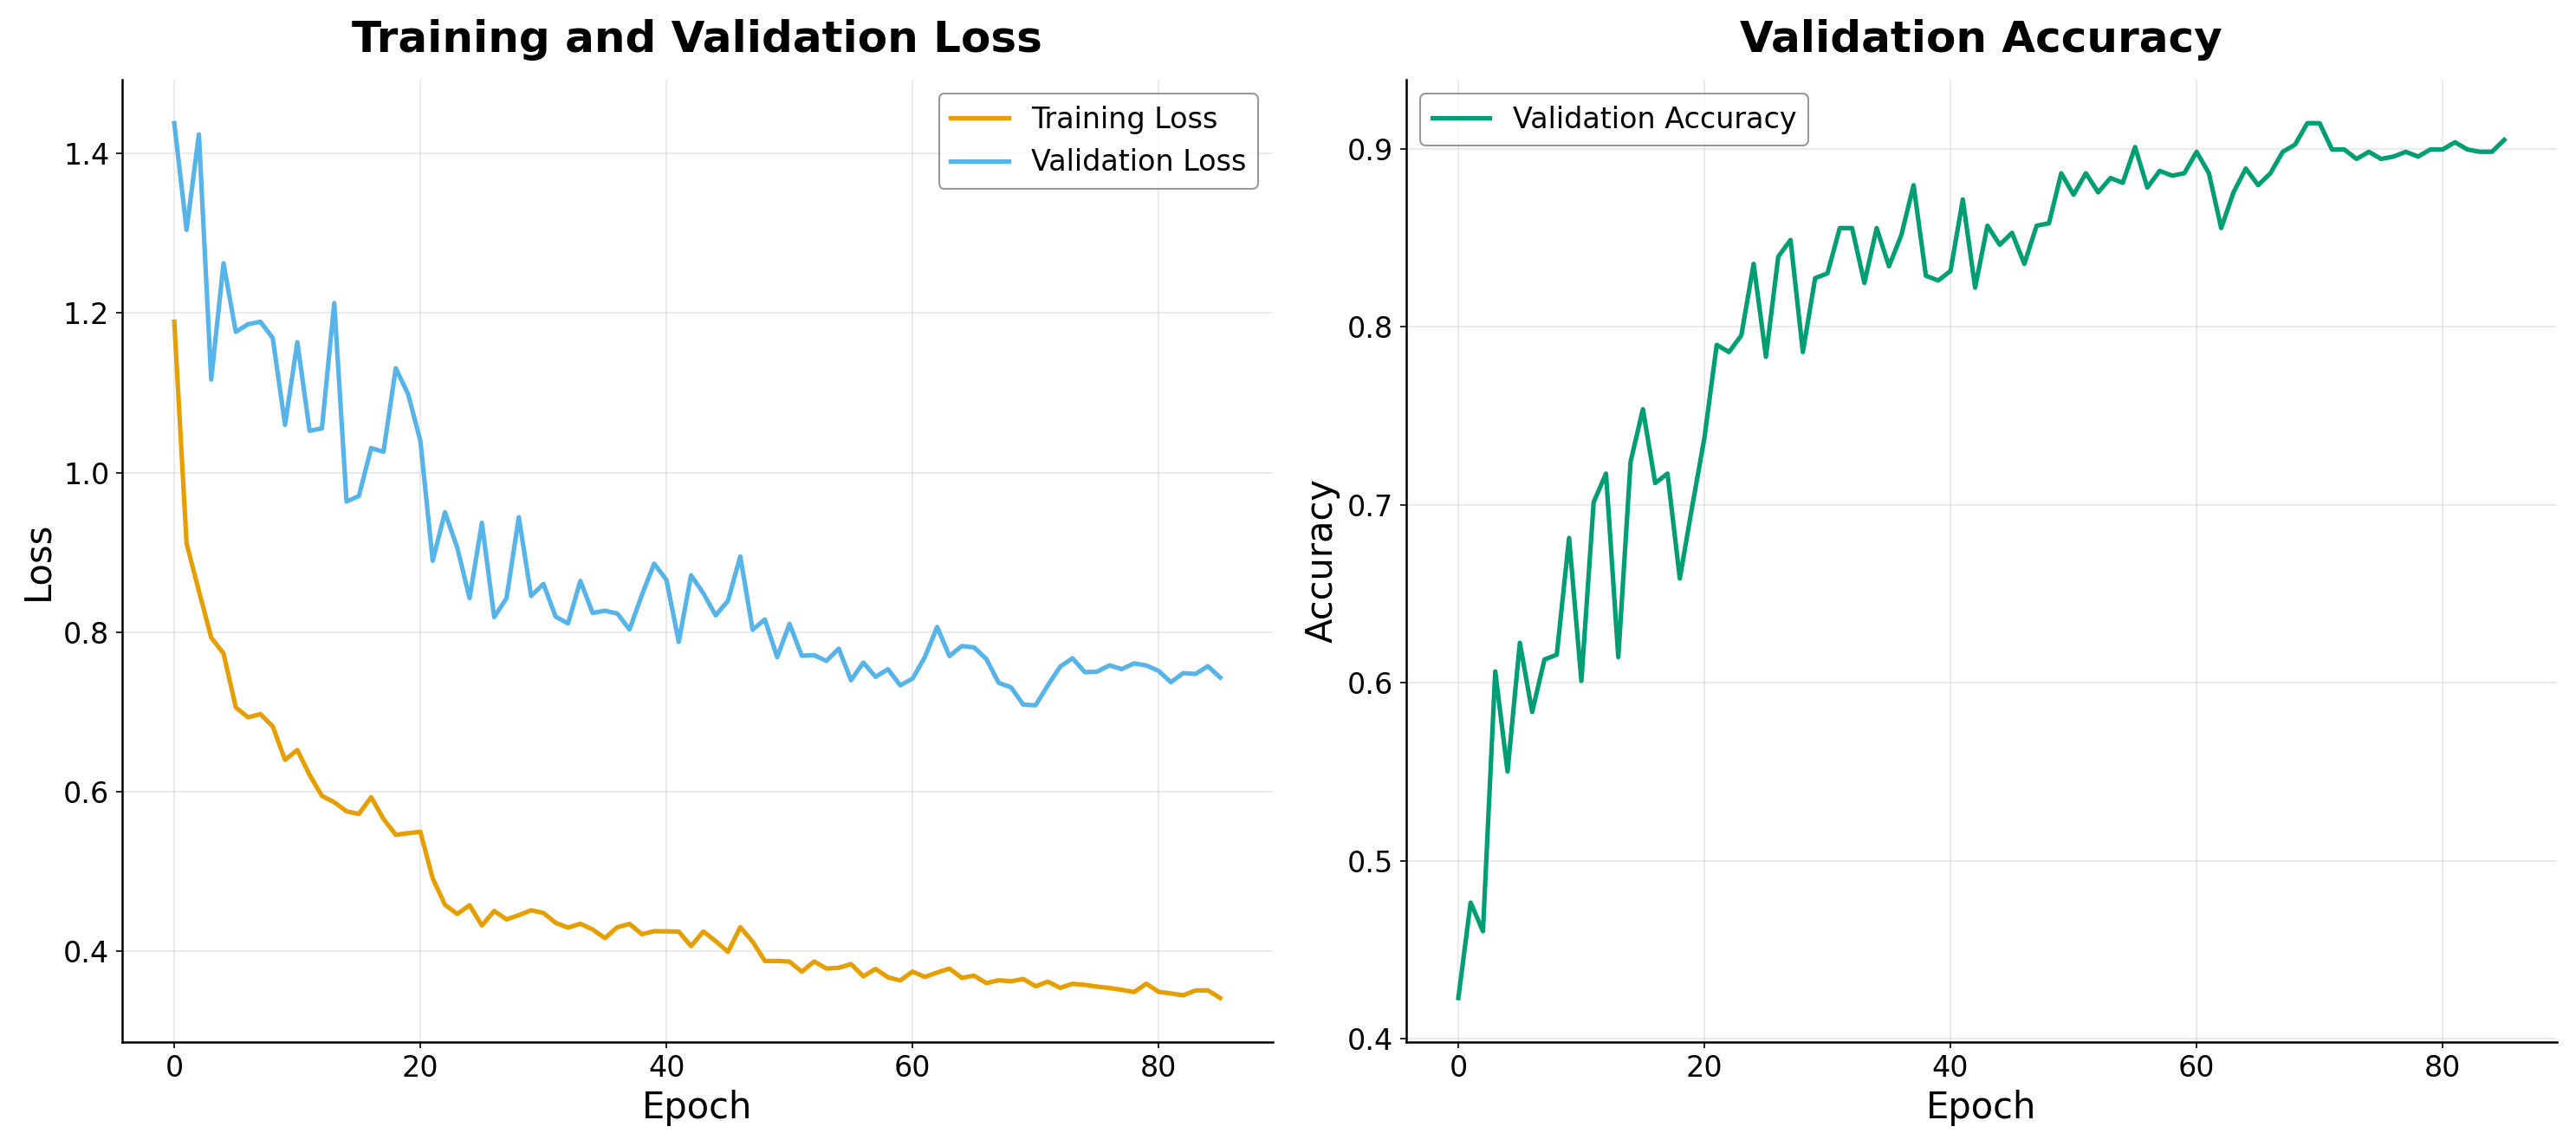

In [9]:
# Step 7: Visualize training history (publication quality)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Loss curves
axes[0].plot(history['train_loss'], label='Training Loss',
             color=CB_PALETTE[0], linewidth=2.5)
axes[0].plot(history['val_loss'], label='Validation Loss',
             color=CB_PALETTE[1], linewidth=2.5)
axes[0].set_title('Training and Validation Loss', fontsize=24, fontweight='bold', pad=15)
axes[0].set_xlabel('Epoch', fontsize=20)
axes[0].set_ylabel('Loss', fontsize=20)
axes[0].legend(fontsize=16, frameon=True, edgecolor='gray')
axes[0].tick_params(axis='both', labelsize=16)
axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(history['val_acc'], label='Validation Accuracy',
             color=CB_PALETTE[2], linewidth=2.5)
axes[1].set_title('Validation Accuracy', fontsize=24, fontweight='bold', pad=15)
axes[1].set_xlabel('Epoch', fontsize=20)
axes[1].set_ylabel('Accuracy', fontsize=20)
axes[1].legend(fontsize=16, frameon=True, edgecolor='gray')
axes[1].tick_params(axis='both', labelsize=16)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Classification Report:
                          precision    recall  f1-score   support

Composite_Rubber_Textile     0.9259    0.8772    0.9009        57
                 Organic     0.9114    0.9231    0.9172        78
                   Paper     0.7895    0.8929    0.8380        84
                 Plastic     0.9312    0.8889    0.9096       198

                accuracy                         0.8945       417
               macro avg     0.8895    0.8955    0.8914       417
            weighted avg     0.8982    0.8945    0.8954       417



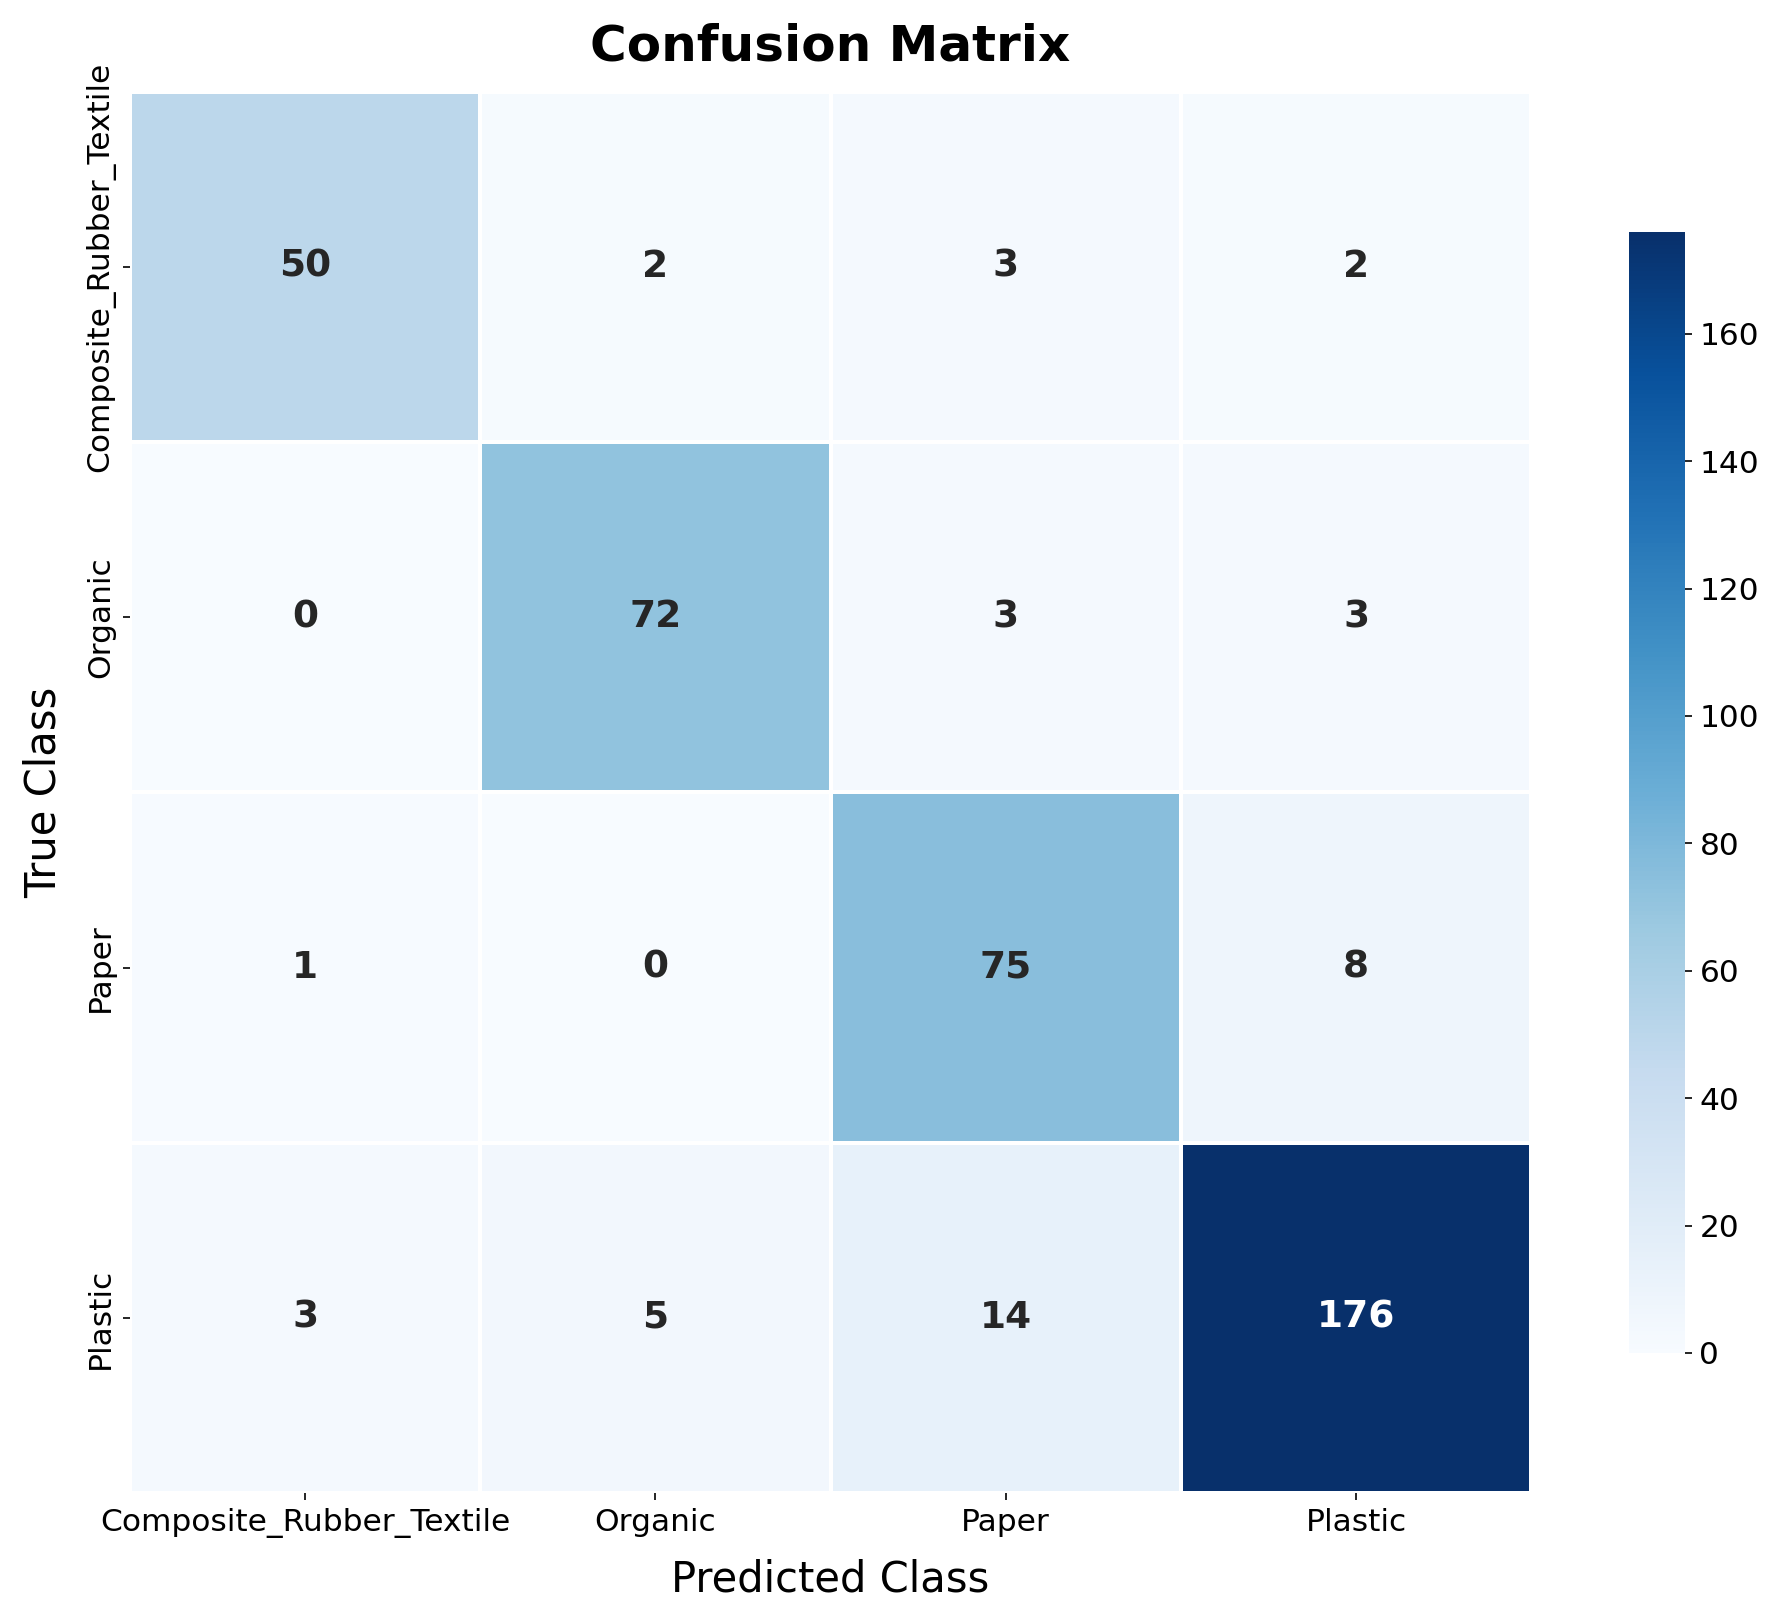

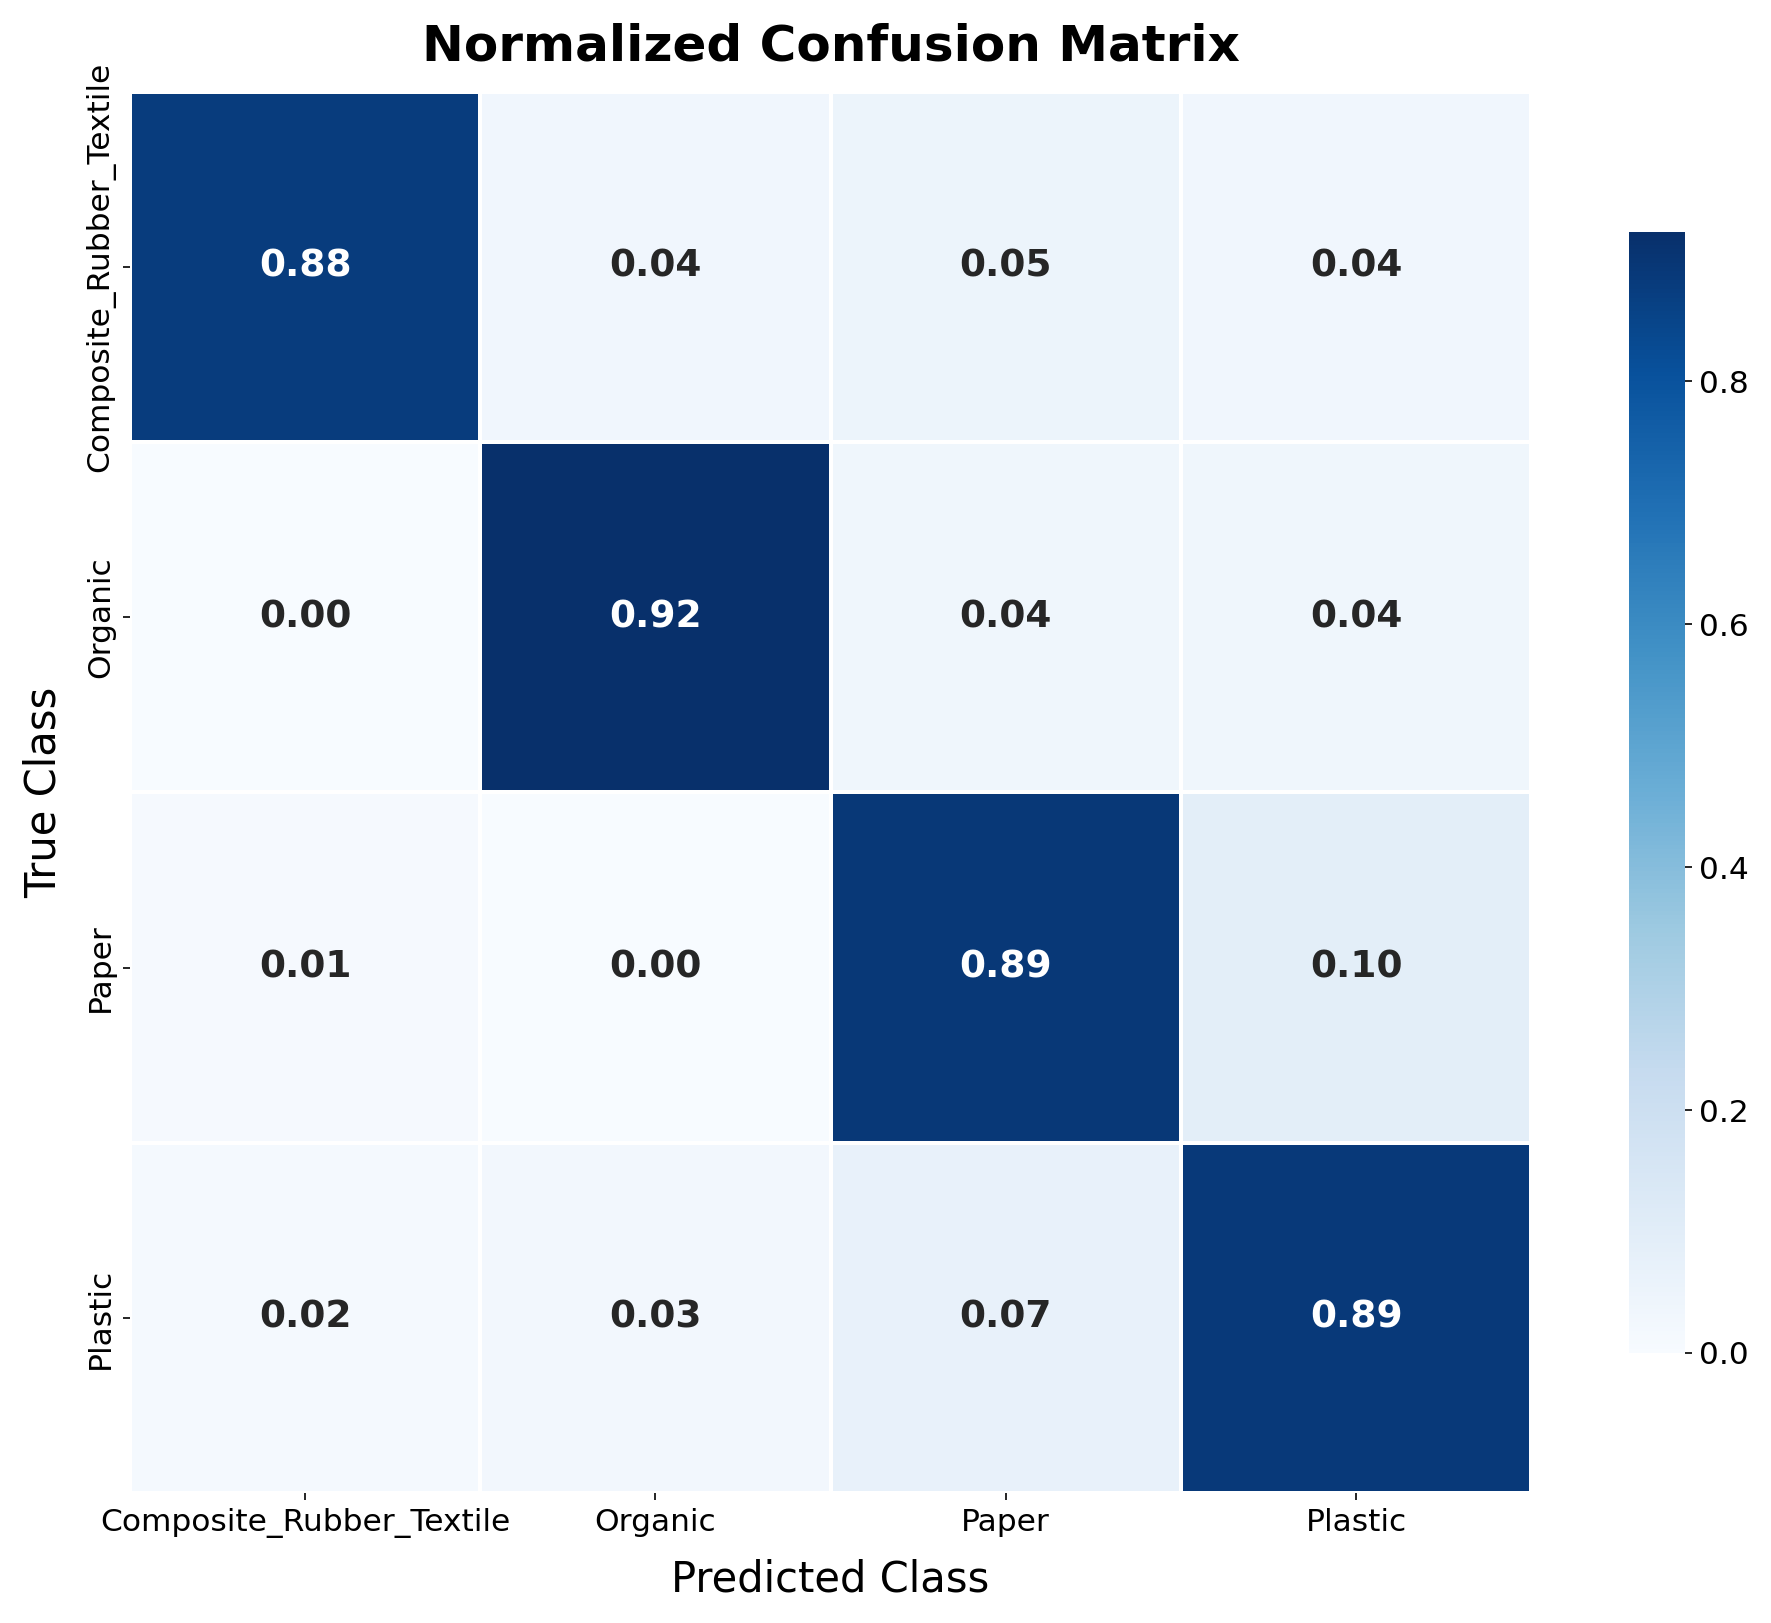

In [10]:
# Step 8: Load best model and evaluate on test set
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best model
model.load_state_dict(torch.load('vit_base_patch16_224_best_model.pth'))
model.eval()

# Evaluate on test set
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate metrics
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Get class names for readability
class_names = [test_ds.id2label[i] for i in range(num_classes)]

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

# Confusion matrix (counts)
cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='white',
    square=True,
    annot_kws={"size": 18, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_xlabel("Predicted Class", fontsize=20, labelpad=10)
ax.set_ylabel("True Class", fontsize=20, labelpad=10)
ax.set_title("Confusion Matrix", fontsize=24, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=1,
    linecolor='white',
    square=True,
    annot_kws={"size": 18, "fontweight": "bold"},
    cbar_kws={"shrink": 0.8},
    ax=ax,
)
ax.set_xlabel("Predicted Class", fontsize=20, labelpad=10)
ax.set_ylabel("True Class", fontsize=20, labelpad=10)
ax.set_title("Normalized Confusion Matrix", fontsize=24, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=15)
plt.tight_layout()
plt.show()